## Data Collection

We collected historical daily closing prices for five assets over a 5-year period using the yfinance API.

The selected assets include both US and European stocks, providing some geographical diversification.

In [233]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [234]:
tickers = ["AAPL", "MSFT", "MC.PA", "TTE", "BNP.PA"]
data = yf.download(tickers, period="5y")
prices = data["Close"]
prices.head()


[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,BNP.PA,MC.PA,MSFT,TTE
Date,,,,,
2021-03-18,117.395668,37.386593,519.039001,221.389618,35.554718
2021-03-19,116.869743,36.156631,510.881775,221.034546,36.164352
2021-03-22,120.181305,35.845608,510.148499,226.446472,35.855770
2021-03-23,119.353424,35.598206,507.948822,227.972183,34.971909
2021-03-24,116.967140,36.135429,507.215607,225.937912,35.652977


In [235]:
prices_clean = prices.dropna()
prices_clean.head()

Ticker,AAPL,BNP.PA,MC.PA,MSFT,TTE
Date,,,,,
2021-03-18,117.395668,37.386593,519.039001,221.389618,35.554718
2021-03-19,116.869743,36.156631,510.881775,221.034546,36.164352
2021-03-22,120.181305,35.845608,510.148499,226.446472,35.855770
2021-03-23,119.353424,35.598206,507.948822,227.972183,34.971909
2021-03-24,116.967140,36.135429,507.215607,225.937912,35.652977


## Price Evolution

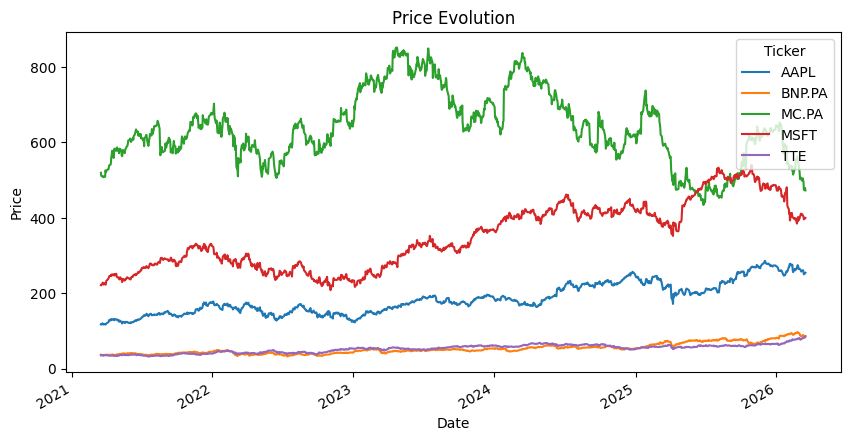

In [236]:
prices_clean.plot(figsize=(10,5))
plt.title("Price Evolution")
plt.xlabel("Date")
plt.ylabel("Price")
plt.savefig("figure/Price_Evolution.png", dpi=300, bbox_inches="tight")
plt.show()

### _Interpretation_

The raw price evolution shows that all assets exhibit an upward trend over the 5-year period.

However, the assets have very different price levels, which makes direct comparison difficult.

This highlights a limitation of using raw prices for analysis.

To address this issue, we normalize the prices to a common base value in order to compare their relative performance.

## Normalized Prices

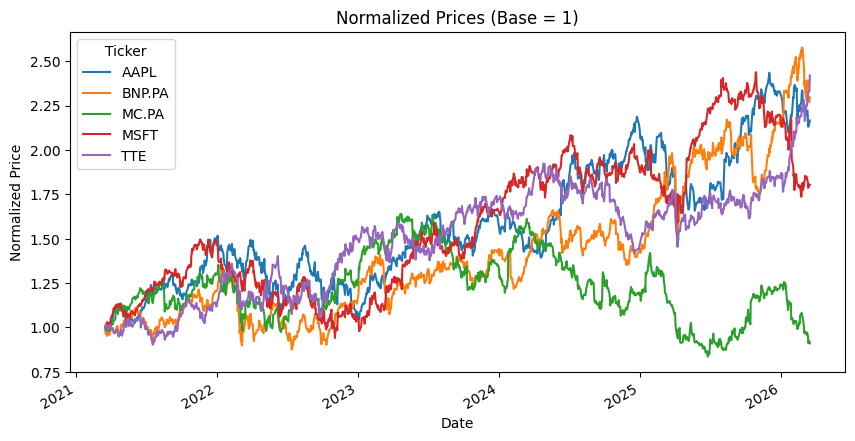

In [237]:
normalized_prices = prices_clean / prices_clean.iloc[0]

normalized_prices.plot(figsize=(10,5))
plt.title("Normalized Prices (Base = 1)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.savefig("figure/Normalized_Price.png", dpi=300, bbox_inches="tight")
plt.show()

### _Interpretation_

After normalization, we can clearly compare the relative performance of each asset.

Some assets outperform others over time, while others show more stable growth.

This highlights differences in return dynamics and risk profiles across assets.

## Returns Analysis

In [238]:
returns = prices_clean.pct_change().dropna()
returns.tail()

Ticker,AAPL,BNP.PA,MC.PA,MSFT,TTE
Date,,,,,
2026-03-11,-0.000077,0.012108,-0.008325,-0.002169,0.015360
2026-03-12,-0.019363,-0.040698,-0.010594,-0.007459,0.001353
2026-03-13,-0.022052,-0.010606,-0.043030,-0.015702,0.016335
2026-03-16,0.010795,-0.000118,0.011188,0.011124,0.001329
2026-03-17,0.005577,0.011781,-0.014092,-0.001350,0.038378


Daily returns are computed as percentage changes in prices.

Returns fluctuate around zero, reflecting short-term market movements.

This transformation allows us to analyze the statistical properties of the assets, such as volatility and correlation.

## Correlation Analysis

In [239]:
corr = returns.corr()
corr

Ticker,AAPL,BNP.PA,MC.PA,MSFT,TTE
Ticker,,,,,
AAPL,1.000000,0.148656,0.257213,0.589891,0.232972
BNP.PA,0.148656,1.000000,0.413437,0.113266,0.385938
MC.PA,0.257213,0.413437,1.000000,0.217104,0.213640
MSFT,0.589891,0.113266,0.217104,1.000000,0.168555
TTE,0.232972,0.385938,0.213640,0.168555,1.000000


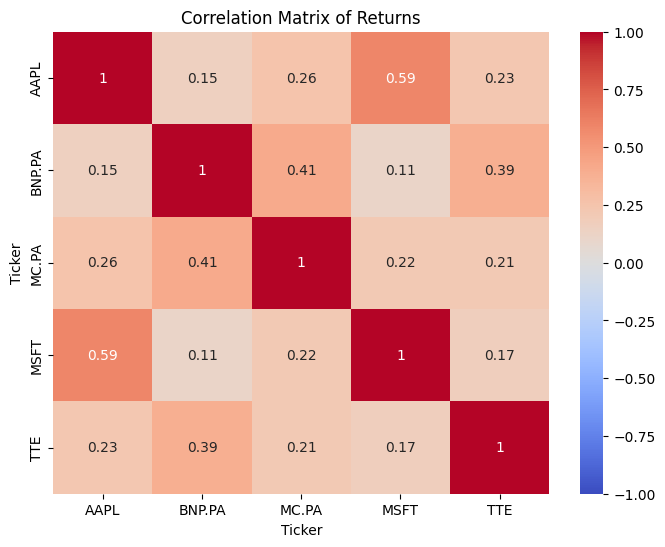

In [240]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Returns")
plt.savefig("figure/Correlation_Matrix_of_Returns.png", dpi=300, bbox_inches="tight")
plt.show()

### _Interpretation_

The correlation matrix shows that all assets are positively correlated, although the strength of the relationships varies.

For example, AAPL and MSFT show a relatively strong correlation (~0.59), which is expected as both belong to the technology sector.

On the other hand, some pairs show lower correlations, such as BNP.PA and MSFT (~0.11), indicating potential diversification benefits.

Overall, the correlations are not perfect, which suggests that combining these assets can reduce portfolio risk through diversification.

## Returns and Volatility

In [241]:
mean_returns = returns.mean()
volatility = returns.std()

print("Daily Mean Return :")
print(mean_returns)

print("\nDaily Volatility :")
print(volatility)

Daily Mean Return :
Ticker
AAPL      0.000771
BNP.PA    0.000830
MC.PA     0.000100
MSFT      0.000613
TTE       0.000840
dtype: float64

Daily Volatility :
Ticker
AAPL      0.017349
BNP.PA    0.017903
MC.PA     0.018826
MSFT      0.016616
TTE       0.016015
dtype: float64


In [242]:
mean_annual = returns.mean() * 252
vol_annual = returns.std() * np.sqrt(252)

print("Annual Mean Return :")
print((mean_annual * 100).round(2))


print("\nAnnual Volatility::")
print((vol_annual * 100).round(2))

Annual Mean Return :
Ticker
AAPL      19.44
BNP.PA    20.93
MC.PA      2.52
MSFT      15.44
TTE       21.16
dtype: float64

Annual Volatility::
Ticker
AAPL      27.54
BNP.PA    28.42
MC.PA     29.88
MSFT      26.38
TTE       25.42
dtype: float64


### _Interpretation_

The annualized returns show significant differences across assets.

BNP.PA and TTE exhibit the highest expected returns, while MC.PA has a much lower return.

In terms of risk, all assets display relatively similar levels of volatility, although MC.PA appears slightly more volatile.

This indicates that some assets provide better return per unit of risk, which will be confirmed by the Sharpe ratio analysis.

## Risk-Free Rate

In [243]:
rf_data = yf.download("^IRX", period="5d") #^IRX = 13 Week Treasury Bill Yield (US)(le rendement des bons du Tresors américain à 3 mois )
rf = rf_data["Close"].iloc[-1] / 100  #on recuppere la derniere valeur avec iloc[-1] et on divise par 100 pour avoir des decimals 
print("Risk-free rate (short term):", rf)


[*********************100%***********************]  1 of 1 completed

Risk-free rate (short term): Ticker
^IRX    0.03605
Name: 2026-03-17 00:00:00, dtype: float64


### _Interpretation_

The risk-free rate is obtained using the 13-week US Treasury Bill (^IRX).

It represents the return of a theoretically risk-free investment and is used as a baseline to evaluate excess returns.

This allows for a more realistic computation of the Sharpe ratio.

## Sharpe Ratio Analysis

In [244]:
rf_value = rf.iloc[0]
sharpe = (mean_annual - rf_value) / vol_annual
print("Sharpe Ratio of Assets:")
print(sharpe.sort_values(ascending=False))

Sharpe Ratio of Assets:
Ticker
TTE       0.690458
BNP.PA    0.609511
AAPL      0.575036
MSFT      0.448625
MC.PA    -0.036384
dtype: float64


### _Interpretation_

The Sharpe ratio measures the return adjusted for risk.

TTE and BNP.PA exhibit the highest Sharpe ratios, indicating a strong risk-return tradeoff.

AAPL and MSFT show moderate performance, while MC.PA has a negative Sharpe ratio, suggesting that it underperforms relative to its level of risk.

This metric helps identify the most efficient assets to include in the portfolio.

## Risk-Return Profile

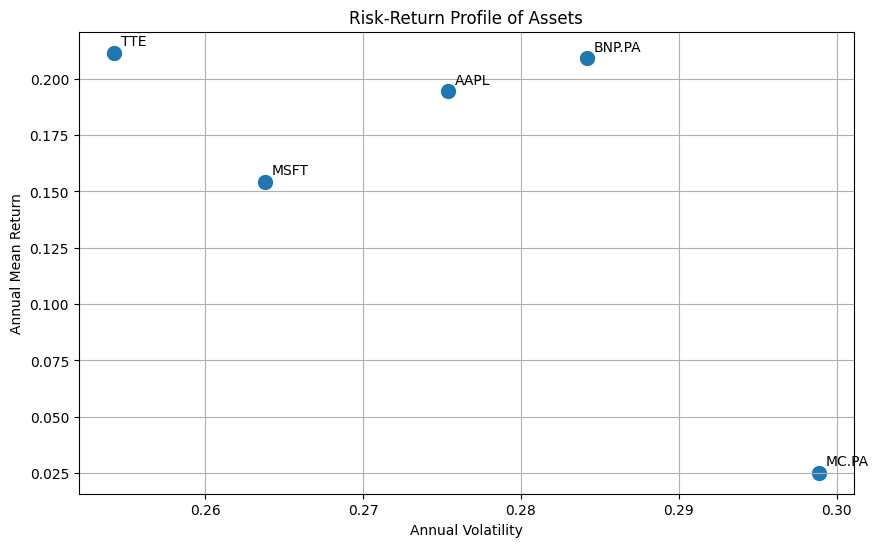

In [245]:
plt.figure(figsize=(10,6))
plt.scatter(vol_annual, mean_annual, s=100)

for ticker in mean_annual.index:
    plt.annotate(ticker, (vol_annual[ticker], mean_annual[ticker]), xytext=(5,5), textcoords="offset points")

plt.title("Risk-Return Profile of Assets")
plt.xlabel("Annual Volatility")
plt.ylabel("Annual Mean Return")
plt.grid(True)
plt.savefig("figure/Risk_Return_Profile_of_Assets.png", dpi=300, bbox_inches="tight")
plt.show()

### _Interpretation_

The scatter plot shows the relationship between annualized return and volatility for each asset.

Assets located higher and to the left are more attractive, as they offer higher returns with lower risk.

TTE and BNP.PA appear particularly attractive, while MC.PA is dominated, as it offers lower return with higher risk.

This visualization helps identify efficient and inefficient assets.

## Equally Weighted Portfolio

As a starting point, we build an equally weighted portfolio by allocating 20% of capital to each asset.

This simple portfolio provides a useful baseline before moving to portfolio optimization.

In [246]:
weights = np.array([0.2,0.2,0.2,0.2,0.2])

In [247]:
rendement_portefeuille = np.sum(weights * mean_annual)
rendement_portefeuille

np.float64(0.15896602120447056)

In [248]:
matrice_covariance = returns.cov() * 252

volatilité_portefeuille = np.sqrt(np.dot(weights.T, np.dot(matrice_covariance, weights)))
volatilité_portefeuille

np.float64(0.17847564362047477)

In [249]:
portfolio_sharpe = (rendement_portefeuille - rf_value) / volatilité_portefeuille
portfolio_sharpe

np.float64(0.6886991329478793)

In [250]:
cov_matrix = returns.cov() * 252
num_assets = len(mean_annual)
asset_names = mean_annual.index

### _Interpretation_

The equally weighted portfolio provides a baseline allocation where each asset contributes the same proportion of capital.

This portfolio achieves an annual return of approximately 15.9% with an annual volatility of about 17.8%, resulting in a Sharpe ratio close to 0.69.

Although simple, this allocation already benefits from diversification, as the portfolio risk is reduced compared to the risk of holding a single asset.

This baseline will be compared to the optimized portfolios identified through Monte Carlo simulation.

## Monte Carlo Simulation

To identify more efficient allocations, we generate 10,000 random portfolios.

For each simulated portfolio, we compute:
- expected annual return
- annual volatility
- Sharpe ratio

This allows us to explore the risk-return space and identify the most efficient portfolios.

In [251]:
num_portfolios = 10000

results = np.zeros((3, num_portfolios))
weights_list = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)   # pour que la somme fasse 1
    
    weights_list.append(weights)
    
    portfolio_return = np.sum(weights * mean_annual)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    portfolio_sharpe = (portfolio_return - rf_value) / portfolio_volatility
    
    results[0, i] = portfolio_return
    results[1, i] = portfolio_volatility
    results[2, i] = portfolio_sharpe

### Structuring Simulation Results

In [252]:
portfolios = pd.DataFrame({
    "Return": results[0],
    "Volatility": results[1],
    "Sharpe": results[2]
})

In [253]:
portfolios.head()

,Return,Volatility,Sharpe
0,0.154403,0.187641,0.630741
1,0.166001,0.182099,0.713630
2,0.189638,0.192134,0.799375
3,0.149321,0.187470,0.604209
4,0.146697,0.180079,0.614438


By structuring the data this way, we can efficiently identify optimal portfolios, such as:
- the portfolio with the highest Sharpe ratio
- the portfolio with the lowest volatility

This step transforms raw simulation outputs into a dataset that can be analyzed using standard data science tools.

## Maximum Sharpe Portfolio

The Maximum Sharpe Portfolio is the portfolio that offers the highest risk-adjusted return among all simulated portfolios.

It represents the most efficient allocation in terms of return per unit of risk.

Compared to the equally weighted portfolio, this optimized portfolio is expected to provide a better balance between performance and volatility.

In [254]:
max_sharpe_idx = portfolios["Sharpe"].idxmax()
max_sharpe_portfolio = portfolios.iloc[max_sharpe_idx]
max_sharpe_weights = weights_list[max_sharpe_idx]

print("Maximum Sharpe Portfolio:")
print(max_sharpe_portfolio)

Maximum Sharpe Portfolio:
Return        0.199614
Volatility    0.185220
Sharpe        0.883076
Name: 3527, dtype: float64


## Minimum Volatility Portfolio

The Minimum Volatility Portfolio is the portfolio with the lowest overall risk among all simulated portfolios.

Its objective is not to maximize return, but rather to minimize fluctuations in portfolio value.

This portfolio is particularly relevant for more risk-averse investors.

In [255]:
min_vol_idx = portfolios["Volatility"].idxmin()
min_vol_portfolio = portfolios.iloc[min_vol_idx]
min_vol_weights = weights_list[min_vol_idx]

print("Minimum Volatility Portfolio:")
print(min_vol_portfolio)

Minimum Volatility Portfolio:
Return        0.166633
Volatility    0.176012
Sharpe        0.741896
Name: 6150, dtype: float64


In [256]:
max_sharpe_allocation = pd.Series(max_sharpe_weights, index=asset_names)
print("Weights of the Maximum Sharpe Portfolio:")
print(max_sharpe_allocation)

Weights of the Maximum Sharpe Portfolio:
Ticker
AAPL      0.284208
BNP.PA    0.292301
MC.PA     0.004630
MSFT      0.097055
TTE       0.321806
dtype: float64


In [257]:
min_vol_allocation = pd.Series(min_vol_weights, index=asset_names)
print("Weights of the Minimum Volatility Portfolio:")
print(min_vol_allocation)

Weights of the Minimum Volatility Portfolio:
Ticker
AAPL      0.126505
BNP.PA    0.164530
MC.PA     0.145351
MSFT      0.267554
TTE       0.296061
dtype: float64


### _Allocation Insights_

We observe that the Maximum Sharpe Portfolio assigns a large weight to TTE and BNP Paribas, indicating that these assets contribute strongly to improving the risk-return trade-off.

On the other hand, MC.PA receives a very small allocation, suggesting that it does not significantly improve portfolio efficiency.

The Minimum Volatility Portfolio shows a more balanced allocation, which helps reduce overall portfolio risk.

These differences illustrate the importance of asset correlations in portfolio optimization.

## Efficient Frontier and Portfolio Visualization

In this section, we visualize the results of the Monte Carlo simulation.

The goal is to better understand the relationship between risk and return, and to identify the most efficient portfolios.

We also highlight key portfolios such as the Maximum Sharpe Portfolio and the Minimum Volatility Portfolio.

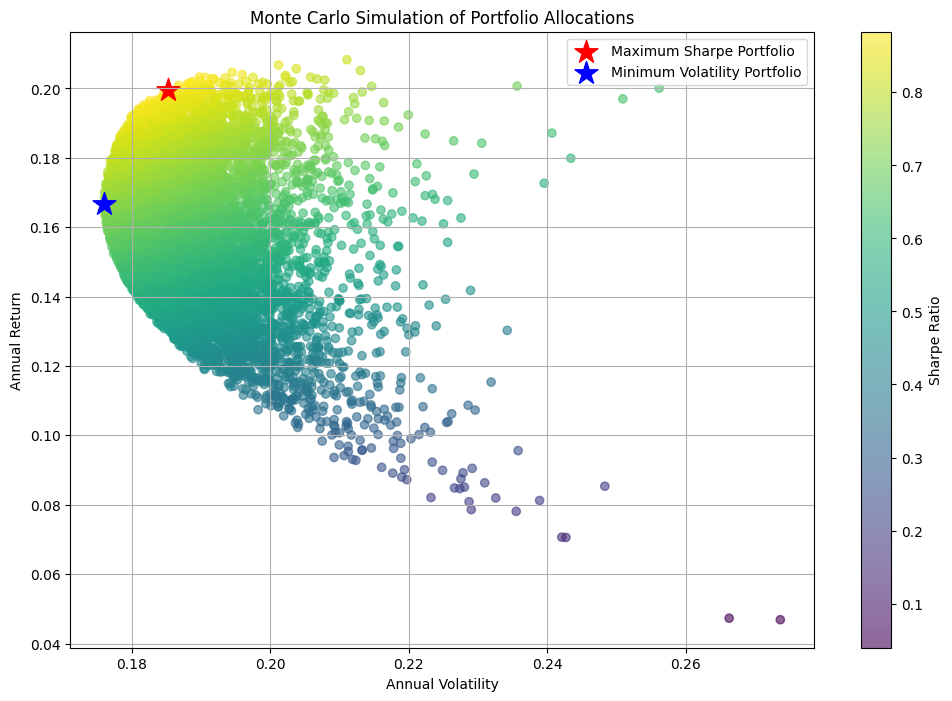

In [258]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    portfolios["Volatility"],
    portfolios["Return"],
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Sharpe Ratio")

plt.scatter(
    max_sharpe_portfolio["Volatility"],
    max_sharpe_portfolio["Return"],
    color="red",
    marker="*",
    s=300,
    label="Maximum Sharpe Portfolio"
)

plt.scatter(
    min_vol_portfolio["Volatility"],
    min_vol_portfolio["Return"],
    color="blue",
    marker="*",
    s=300,
    label="Minimum Volatility Portfolio"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Monte Carlo Simulation of Portfolio Allocations")



plt.legend()
plt.grid(True)
plt.savefig("figure/Monte_Carlo_Simulation_of_Portfolio_Allocations.png", dpi=300, bbox_inches="tight")
plt.show()

### _Interpretation_

The scatter plot represents 10,000 randomly generated portfolios.

Each point corresponds to a specific allocation of assets, with:
- the x-axis representing portfolio volatility (risk)
- the y-axis representing expected return
- the color indicating the Sharpe ratio

We observe a clear trade-off between risk and return:
- portfolios with higher returns generally exhibit higher volatility
- lower-risk portfolios tend to have lower expected returns

The red star represents the Maximum Sharpe Portfolio, which offers the best risk-adjusted return.

The blue star represents the Minimum Volatility Portfolio, which minimizes risk regardless of return.

The upper boundary of the cloud of points forms the Efficient Frontier.

This frontier represents the set of optimal portfolios that maximize return for a given level of risk.

Rational investors should only choose portfolios located on this frontier.

### Optimal Portfolio Allocation

This chart shows the composition of the optimal portfolio obtained by maximizing the Sharpe ratio.

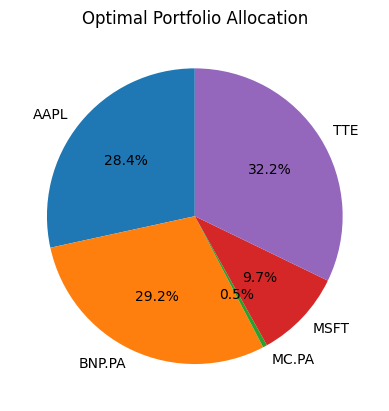

In [259]:
plt.pie(max_sharpe_allocation, labels=max_sharpe_allocation.index, autopct="%1.1f%%", startangle=90)
plt.title("Optimal Portfolio Allocation")
plt.savefig("figure/allocation.png", dpi=300, bbox_inches="tight")
plt.show()


### _Interpretation_

The optimal portfolio is diversified across several assets, with a higher allocation to BNP.PA and TTE, which together represent more than half of the portfolio.

AAPL and MSFT also contribute significantly, reflecting their strong risk-return profiles. In contrast, MC.PA has a very low weight, suggesting that it does not provide an attractive contribution to the portfolio in terms of Sharpe ratio.

Overall, the allocation highlights a balance between return and risk, favoring assets with higher expected returns relative to their volatility.

### Definition of the Efficient Frontier

The efficient frontier is a fundamental concept in Modern Portfolio Theory.

It represents the set of optimal portfolios that offer the highest expected return for a given level of risk, or equivalently, the lowest risk for a given level of return.

In other words, any portfolio located below the efficient frontier is considered suboptimal, as a better combination of risk and return exists.

Investors seeking rational and efficient allocations should therefore focus only on portfolios lying on this frontier.

### Efficient Frontier Construction

To explicitly identify the efficient frontier, we sort portfolios by volatility and retain only those that offer increasing returns.

This allows us to extract the upper envelope of the simulated portfolios.

In [260]:
# Trier les portefeuilles par volatilité
sorted_portfolios = portfolios.sort_values("Volatility")

efficient_returns = []
efficient_volatility = []

max_return = -np.inf

for vol, ret in zip(sorted_portfolios["Volatility"], sorted_portfolios["Return"]):
    
    if ret > max_return:
        efficient_volatility.append(vol)
        efficient_returns.append(ret)
        max_return = ret

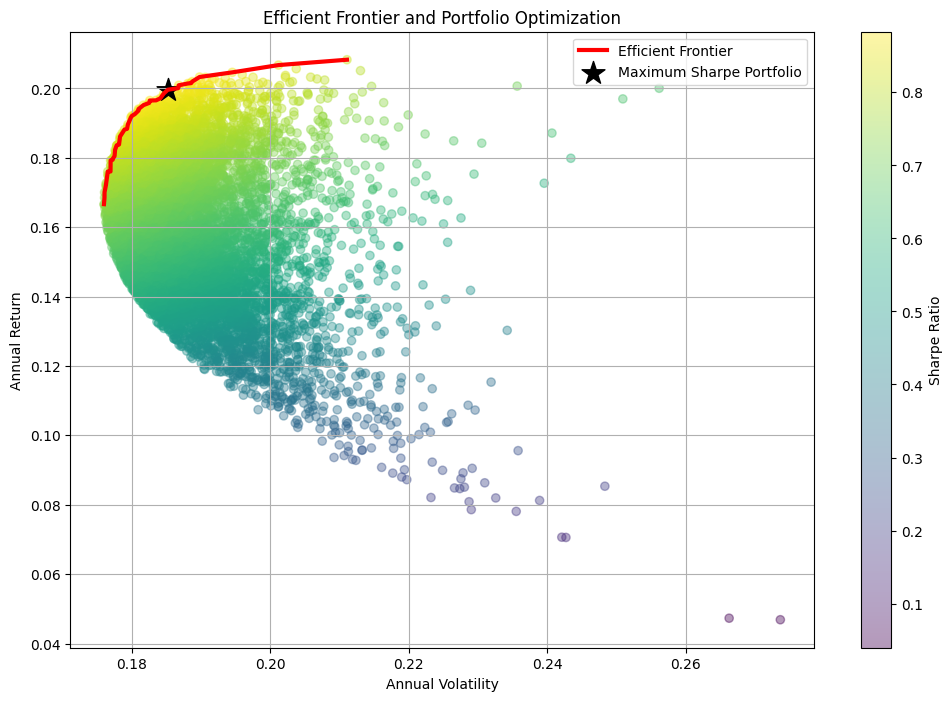

In [261]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    portfolios["Volatility"],
    portfolios["Return"],
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.4
)

plt.plot(
    efficient_volatility,
    efficient_returns,
    color="red",
    linewidth=3,
    label="Efficient Frontier"
)

plt.scatter(
    max_sharpe_portfolio["Volatility"],
    max_sharpe_portfolio["Return"],
    color="black",
    marker="*",
    s=300,
    label="Maximum Sharpe Portfolio"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Efficient Frontier and Portfolio Optimization")
plt.legend()
plt.grid(True)
plt.colorbar(scatter, label="Sharpe Ratio")

plt.savefig("figure/efficient_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

### _Interpretation_ 

The red curve represents the efficient frontier.

It highlights the best achievable trade-offs between risk and return.

Any portfolio located below the frontier is suboptimal, as there exists another portfolio with:
- higher return for the same level of risk, or
- lower risk for the same level of return

The Maximum Sharpe Portfolio lies on this frontier and represents the optimal choice for a risk-balanced investor.

This visualization confirms the relevance of Modern Portfolio Theory in identifying efficient allocations.

## Out-of-Sample Backtesting and Benchmark Comparison

To evaluate the robustness of our portfolio optimization, we perform an out-of-sample backtest.

We split the dataset into:
- 80% for training (portfolio optimization)
- 20% for testing (performance evaluation)

This approach allows us to assess whether the optimized portfolio generalizes well to unseen data.

### Train/Test Split

We divide the historical returns into training and testing sets.

The training set is used to build the model, while the test set is used for evaluation.

In [262]:
split_index = int(len(returns) * 0.8)

train_returns = returns.iloc[:split_index]
test_returns = returns.iloc[split_index:]

print("Train shape :", train_returns.shape)
print("Test shape :", test_returns.shape)

Train shape : (994, 5)
Test shape : (249, 5)


In [263]:
train_mean_annual = train_returns.mean() * 252
train_cov_matrix = train_returns.cov() * 252

### Portfolio Optimization on Training Data

We perform the Monte Carlo simulation using only the training data to determine the optimal portfolio weights.

This avoids data leakage and ensures a fair evaluation.

In [264]:
num_assets = len(train_mean_annual)
asset_names = train_mean_annual.index

num_portfolios = 10000
results_train = np.zeros((3, num_portfolios))
weights_list_train = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    
    weights_list_train.append(weights)
    
    portfolio_return = np.sum(weights * train_mean_annual)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(train_cov_matrix, weights)))
    portfolio_sharpe = (portfolio_return - rf_value) / portfolio_volatility
    
    results_train[0, i] = portfolio_return
    results_train[1, i] = portfolio_volatility
    results_train[2, i] = portfolio_sharpe

### Optimal Portfolio Selection

We identify the portfolio that maximizes the Sharpe ratio on the training dataset.

In [265]:
portfolios_train = pd.DataFrame({
    "Return": results_train[0],
    "Volatility": results_train[1],
    "Sharpe": results_train[2]
})

max_sharpe_idx_train = portfolios_train["Sharpe"].idxmax()
optimal_weights = weights_list_train[max_sharpe_idx_train]

optimal_allocation = pd.Series(optimal_weights, index=asset_names)
print("Poids optimaux obtenus sur le train :")
print(optimal_allocation)

Poids optimaux obtenus sur le train :
Ticker
AAPL      0.292535
BNP.PA    0.262090
MC.PA     0.001850
MSFT      0.218063
TTE       0.225461
dtype: float64


### Out-of-Sample Performance

We apply the optimized weights to the test dataset to simulate real-world performance.

In [266]:
portfolio_test_returns = test_returns.dot(optimal_weights)
portfolio_test_returns.head()

Date
2025-03-17    0.008084
2025-03-18    0.005561
2025-03-19    0.011353
2025-03-20   -0.008652
2025-03-21    0.007941
dtype: float64

### Cumulative Returns

We compute the cumulative performance of the portfolio over the test period.

In [267]:
portfolio_test_cumulative = (1 + portfolio_test_returns).cumprod()
portfolio_test_cumulative.head()

Date
2025-03-17    1.008084
2025-03-18    1.013690
2025-03-19    1.025199
2025-03-20    1.016329
2025-03-21    1.024399
dtype: float64

### Benchmark Comparison

We compare the optimized portfolio to the S&P 500 index, a widely used market benchmark.



In [268]:
benchmark_data = yf.download("^GSPC", start=test_returns.index[0], end=test_returns.index[-1])
benchmark_prices = benchmark_data["Close"]
benchmark_returns = benchmark_prices.pct_change().dropna()
benchmark_cumulative = (1 + benchmark_returns).cumprod()

[*********************100%***********************]  1 of 1 completed


In [269]:
benchmark_cumulative = benchmark_cumulative.squeeze()
comparison = pd.concat(
    [portfolio_test_cumulative.rename("Optimal Portfolio"),
     benchmark_cumulative.rename("S&P 500")],
    axis=1
).dropna()

C:\Users\user\AppData\Local\Temp\ipykernel_3340\47372393.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  comparison = pd.concat(


### Performance Visualization

The following plot compares the cumulative returns of the optimized portfolio and the benchmark.

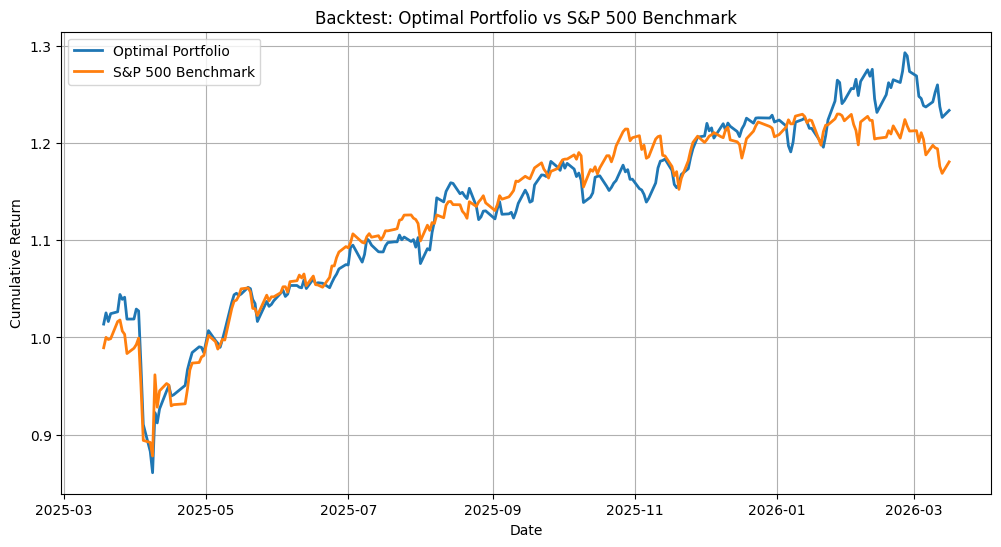

In [270]:
plt.figure(figsize=(12,6))
plt.plot(comparison.index, comparison["Optimal Portfolio"], label="Optimal Portfolio", linewidth=2)
plt.plot(comparison.index, comparison["S&P 500"], label="S&P 500 Benchmark", linewidth=2)
plt.title("Backtest: Optimal Portfolio vs S&P 500 Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)

plt.savefig("figure/backtest.png", dpi=300, bbox_inches="tight")  # ✅ ajout

plt.show()

The optimized portfolio appears to slightly outperform the S&P 500 over the test period.

This suggests that the portfolio optimization method may provide additional value compared to a passive strategy.

In [271]:
test_total_return = comparison["Optimal Portfolio"].iloc[-1] - 1
benchmark_total_return = comparison["S&P 500"].iloc[-1] - 1

print("Performance cumulée du portefeuille optimal :", round(test_total_return * 100, 2), "%")
print("Performance cumulée du S&P 500 :", round(benchmark_total_return * 100, 2), "%")

Performance cumulée du portefeuille optimal : 23.34 %
Performance cumulée du S&P 500 : 18.05 %


The optimized portfolio achieved a higher cumulative return than the benchmark.

However, this result should be interpreted with caution due to potential overfitting and the absence of transaction costs.

### Risk Analysis: Maximum Drawdown

We evaluate the maximum drawdown to measure downside risk.

In [272]:
cum = comparison["Optimal Portfolio"]
rolling_max = cum.cummax()
drawdown = cum / rolling_max - 1
max_drawdown = drawdown.min()

print("Maximum drawdown du portefeuille optimal :", round(max_drawdown * 100, 2), "%")

Maximum drawdown du portefeuille optimal : -17.55 %


In [273]:
cum_bench = comparison["S&P 500"]
rolling_max_bench = cum_bench.cummax()
drawdown_bench = cum_bench / rolling_max_bench - 1
max_drawdown_bench = drawdown_bench.min()

print("Maximum drawdown du S&P 500 :", round(max_drawdown_bench * 100, 2), "%")

Maximum drawdown du S&P 500 : -13.74 %


The optimized portfolio experiences a larger drawdown than the benchmark. This indicates that higher returns come at the cost of higher risk.

This trade-off is consistent with financial theory.

### _Conclusion_

The optimized portfolio outperforms the benchmark in terms of return.

However, it also exhibits higher risk, as shown by the larger drawdown.

This highlights the importance of balancing risk and return when constructing investment strategies.